# Homogeneity score, completeness score, v_measure

- scikit-learn's implementation, textbook algorithms and back-of-envelop calculations

In [1]:
from sklearn import metrics, datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

## Example 1

In [2]:
# the next 5 lines for y and p are just to produce a cross tabulation containing
# unique values easy for demo purpose
y = [0] * 6
y.extend( [1] * 15)
y.extend( [2] * 24)
p = [0, 1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0,
     0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2]
df = pd.DataFrame(list(zip(y, p)), columns=['y', 'p'])
pd.crosstab(df.y, df.p, margins=True)

p,0,1,2,All
y,,,,
0,1,2,3,6
1,4,5,6,15
2,7,8,9,24
All,12,15,18,45


#### Scikit-learn

In [3]:
metrics.homogeneity_completeness_v_measure(y, p)

(0.005631983988002929, 0.0050347713721229535, 0.0053166592452378834)

#### Manual back-of-envelop calculation

In [4]:
Hy = -6/45*np.log(6/45) -15/45*np.log(15/45) -24/45*np.log(24/45)
Hp = -12/45*np.log(12/45) -15/45*np.log(15/45) -18/45*np.log(18/45)
Hyp = (-1/12*np.log(1/12) -4/12*np.log(4/12) -7/12*np.log(7/12) ) * 12/45 + \
      (-2/15*np.log(2/15) -5/15*np.log(5/15) -8/15*np.log(8/15) ) * 15/45 + \
      (-3/18*np.log(3/18) -6/18*np.log(6/18) -9/18*np.log(9/18) ) * 18/45
Hpy = (-1/6*np.log(1/6) -2/6*np.log(2/6) -3/6*np.log(3/6) ) * 6/45 + \
      (-4/15*np.log(4/15) -5/15*np.log(5/15) -6/15*np.log(6/15) ) * 15/45 +\
      (-7/24*np.log(7/24) -8/24*np.log(8/24) -9/24*np.log(9/24) ) * 24/45
homogeneity = 1 - Hyp / Hy
completeness = 1 - Hpy / Hp
v_measure = 2 * homogeneity * completeness / (homogeneity + completeness)
print(homogeneity, completeness, v_measure)

0.005631983988003131 0.005034771372123159 0.005316659245238088


#### Putting back-of-envelop calculation into code

In [5]:
def mycalc(df):
    ct = pd.crosstab(df.y, df.p, margins=True).values
    Hy, Hp, Hyp, Hpy = 0, 0, 0, 0
    for py in ct[:-1, -1]/ct[-1, -1]:
        Hy += -py * np.log(py)
    for pp in ct[-1, :-1]/ct[-1, -1]:
        Hp += -pp * np.log(pp)
    for col in range(ct.shape[1]-1):
        pp = ct[-1, col]
        for row in range(ct.shape[0]-1):
            pij = ct[row, col]
            if pij != 0:
                Hyp -= pij/pp * np.log(pij/pp) * pp / ct[-1, -1]
    for row in range(ct.shape[0]-1):
        py = ct[row, -1]
        for col in range(ct.shape[1]-1):
            pij = ct[row, col]
            if pij != 0:
                Hpy -= pij/py * np.log(pij/py) * py / ct[-1, -1]
    homogeneity = 1 - Hyp / Hy
    completeness = 1 - Hpy / Hp
    v_measure = 2 * homogeneity * completeness / (homogeneity + completeness)
    print(homogeneity, completeness, v_measure)
mycalc(df)

0.005631983988003464 0.005034771372123159 0.0053166592452382365


## Example 2

In [6]:
np.random.seed(0)
n_samples = 1000
X, y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.01)

In [7]:
def plottis(X, y, p):
    plt.set_cmap('Set1')
    plt.scatter(X[:, 0], X[:, 1], c=p, s=3)
    plt.axis('equal');  plt.axis('off')
    plt.title('h={:.1e}, c={:.1e}, v={:.1e}'.format(*metrics.homogeneity_completeness_v_measure(y, p)))

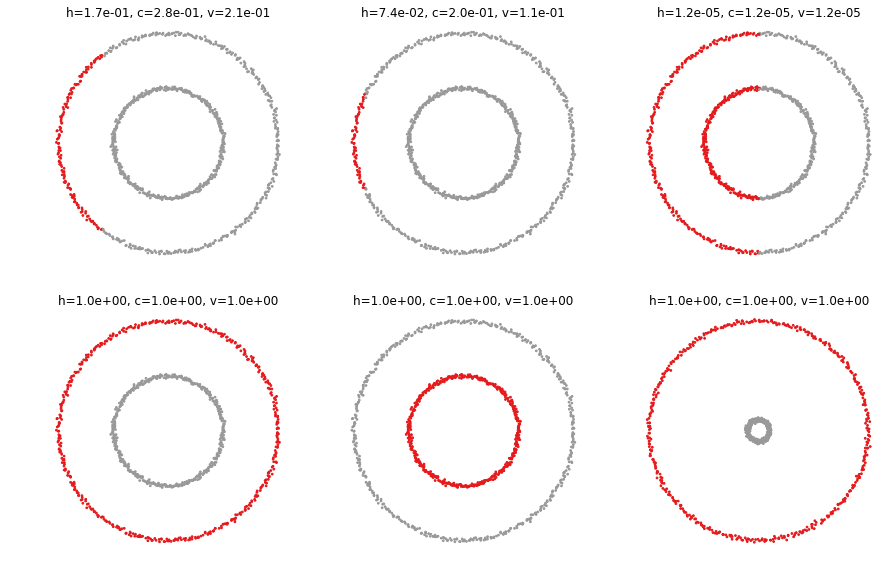

In [8]:
plt.figure(figsize=(15, 15))
plt.subplot(331)
p = np.zeros(len(y))
p[X[:, 0]>-.6] = 1
plottis(X, y, p)

plt.subplot(332)
p = np.zeros(len(y))
p[X[:, 0]>-.9] = 1
plottis(X, y, p)

plt.subplot(333)
p = np.zeros(len(y))
p[X[:, 0]>0] = 1
plottis(X, y, p)

plt.subplot(334)
p = y.copy()
plottis(X, y, p)

plt.subplot(335)
p = np.zeros(len(y))
p[y==0] = 1
plottis(X, y, p)

plt.subplot(336)
X, y = datasets.make_circles(n_samples=n_samples, factor=.1, noise=.01)
p = y.copy()
plottis(X, y, p)

## Example 3

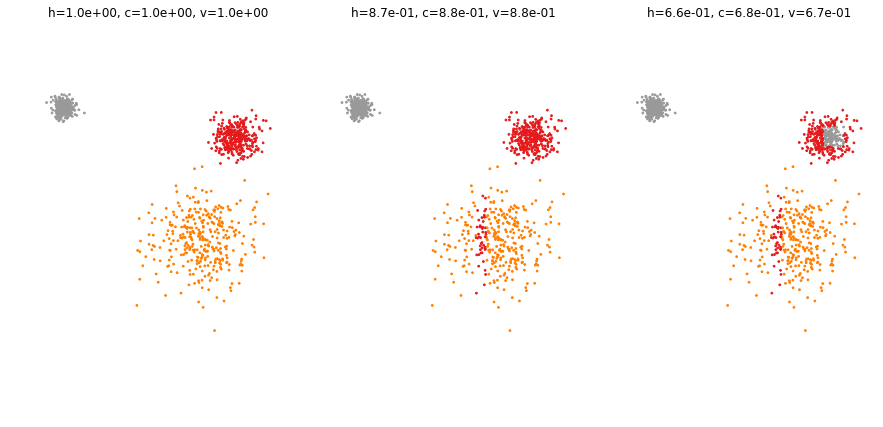

In [9]:
plt.figure(figsize=(15, 7))
plt.subplot(131)
X, y = datasets.make_blobs(n_samples=n_samples, cluster_std=[1, 2.5, .5], random_state=77)
p = y.copy()
plottis(X, y, p)
plt.subplot(132)
p = y.copy()
p[(X[:, 0]>3) & (X[:, 0]<4)] = 0
plottis(X, y, p)
plt.subplot(133)
p = y.copy()
p[(X[:, 0]>3) & (X[:, 0]<4)] = 0
p[(X[:, 0]>8) & (X[:, 0]<10) & (X[:, 1]>2) & (X[:, 1]<4)] = 2
plottis(X, y, p)

## Example 4

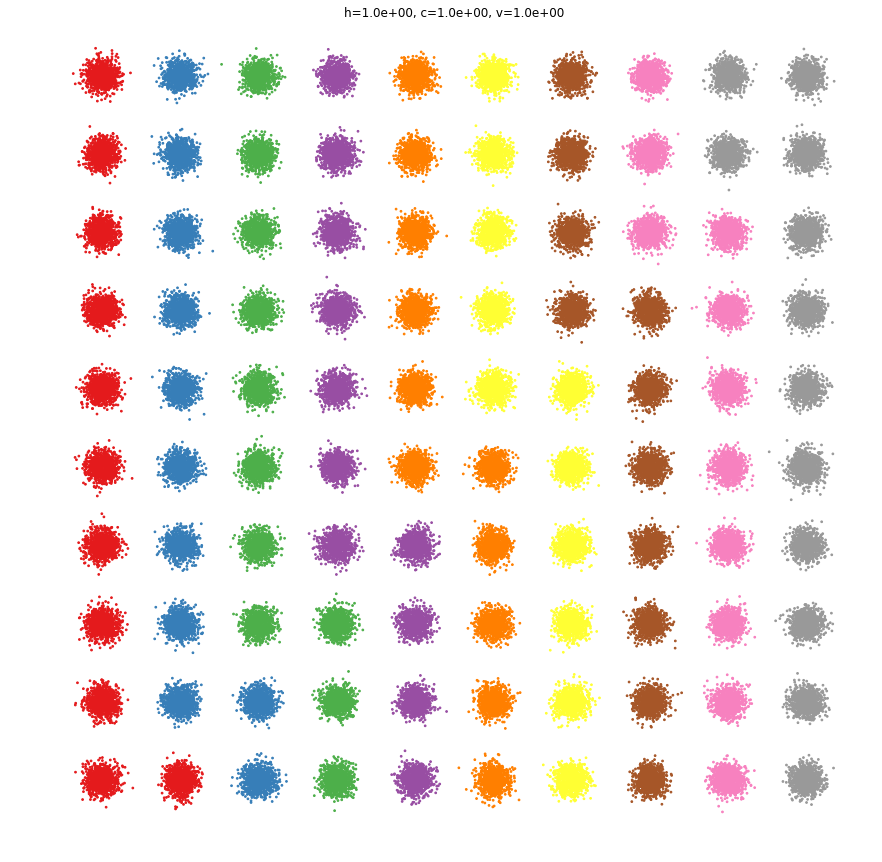

In [10]:
centres = []
for i in np.arange(-50, 50, 10):
    for j in np.arange(-50 ,50, 10):
        centres.append([i, j])
X, y = datasets.make_blobs(n_samples=n_samples*100, centers=centres, random_state=77)
p = y.copy()
plt.figure(figsize=(15, 15))
plottis(X, y, p)

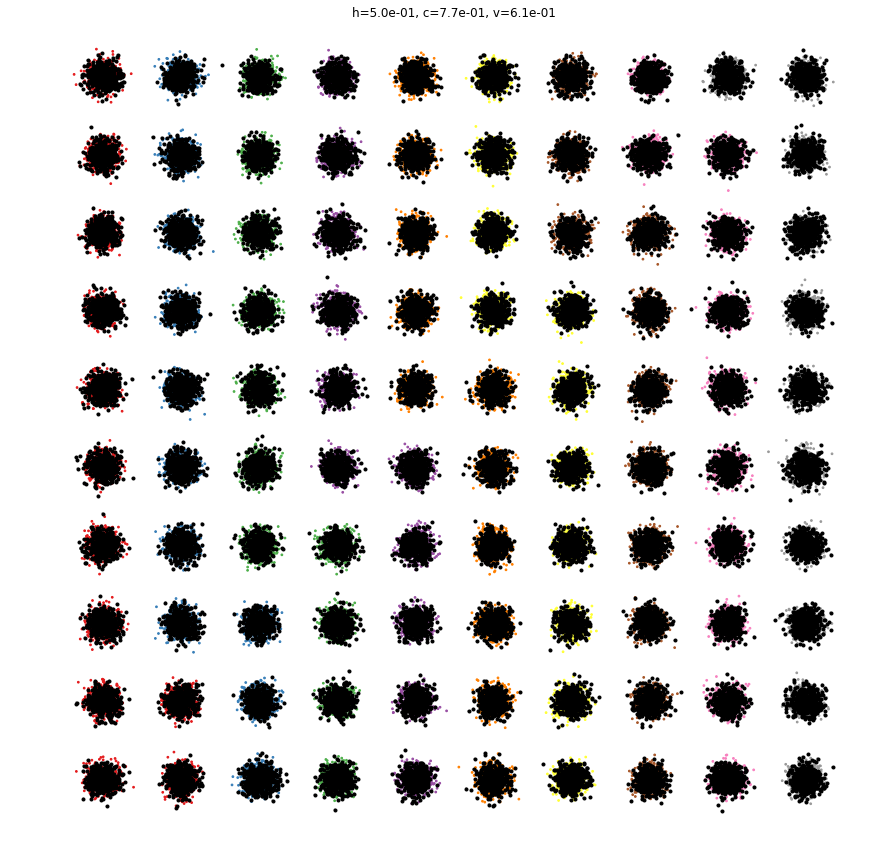

In [11]:
plt.figure(figsize=(15, 15))
p = y.copy()
# create an additional cluster and assign to it half of the points from each of the existing clusters
for i in range(100):
    j = np.where(p==i)[0][:500]
    p[j] = 1 + y.max()
    plt.plot(X[j, 0], X[j, 1], '.k', linewidth=.1)
plottis(X, y, p)